<a href="https://colab.research.google.com/github/Chakshu31106/IITR-/blob/main/IV_SURFACE_RECONSTRUCTION_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finclub Open Project 2026
# Implied Volatility Surface Reconstruction

## Approach
- CE/PE Surface Separation
- Log-Moneyness Polynomial Fitting (degree-3)
- ATM-Weighted Fitting — sharpness=2300
- Edge Stabilisation — slope in raw strike space
- Temporal Fallback Interpolation

**Kaggle-tuned parameters:**

| Parameter | Value | Role |
|-----------|-------|------|
| `SHARPNESS` | 2300 | Deep OTM strikes get near-zero weight |
| `W_POLY` | 0.13 | 13% poly + 87% linear for edge predictions |

**Workflow:**
1. Fill all missing values → save as `filled_dataset.csv`
2. Run the official competition converter → produces `submission.csv`

Author: Chakshu


# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
import seaborn as sns

# Upload Dataset

In [2]:
from google.colab import files

uploaded = files.upload()
# Upload dataset.csv when prompted

Saving dataset.csv to dataset.csv


# Dataset Load

In [3]:
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
print()
df.head()

Shape: (975, 30)



,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,...,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,...,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


# Dataset Overview

In [4]:
print(df.info())

print("\nMissing Values:")
print(df.isna().sum())

print("\nTotal Missing:", df.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 975 entries, 0 to 974
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             975 non-null    object 
 1   underlying_price     975 non-null    float64
 2   NIFTY27JAN2625200CE  781 non-null    float64
 3   NIFTY27JAN2625300CE  791 non-null    float64
 4   NIFTY27JAN2625400CE  773 non-null    float64
 5   NIFTY27JAN2625500CE  794 non-null    float64
 6   NIFTY27JAN2625600CE  795 non-null    float64
 7   NIFTY27JAN2625700CE  774 non-null    float64
 8   NIFTY27JAN2625800CE  765 non-null    float64
 9   NIFTY27JAN2625900CE  793 non-null    float64
 10  NIFTY27JAN2626000CE  794 non-null    float64
 11  NIFTY27JAN2626100CE  792 non-null    float64
 12  NIFTY27JAN2626200CE  766 non-null    float64
 13  NIFTY27JAN2626300CE  788 non-null    float64
 14  NIFTY27JAN2626400CE  762 non-null    float64
 15  NIFTY27JAN2626500CE  791 non-null    flo

# Missing Value Visualisation

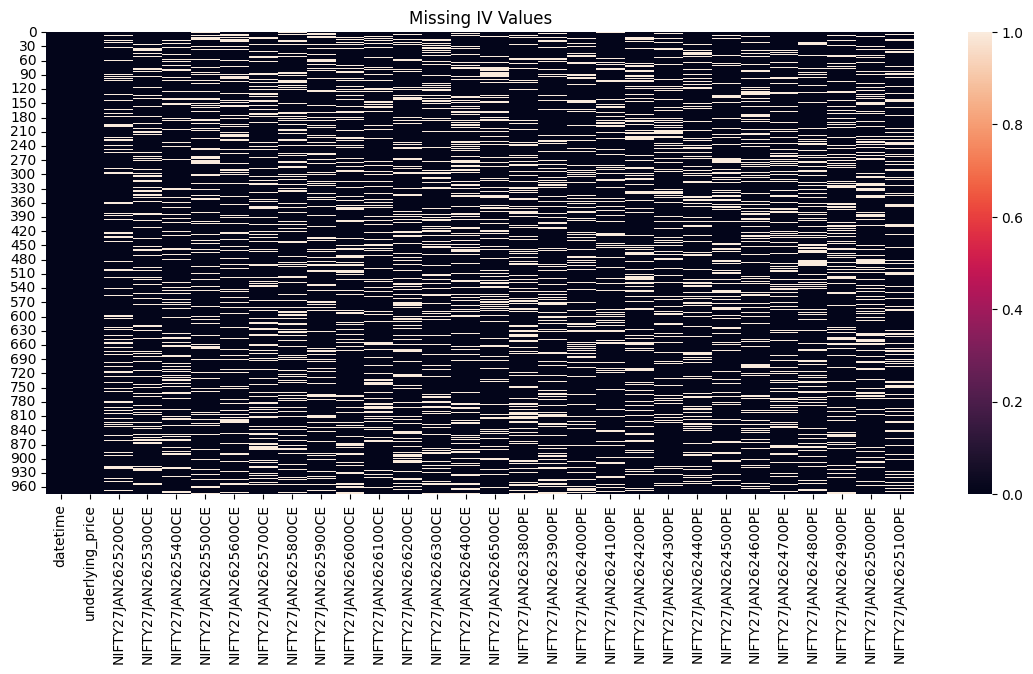

In [5]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull())
plt.title("Missing IV Values")
plt.show()

# Extract Strike Metadata

In [6]:
feature_cols = [
    c for c in df.columns
    if c not in ["datetime", "underlying_price"]
]

col_meta = {}
for c in feature_cols:
    col_meta[c] = {
        "type"  : "CE" if "CE" in c else "PE",
        "strike": int(
            c.replace("NIFTY27JAN26", "")
             .replace("CE", "")
             .replace("PE", "")
        )
    }

# Creating CE and PE Surfaces

In [7]:
ce_cols = sorted(
    [c for c in feature_cols if "CE" in c],
    key=lambda x: col_meta[x]["strike"]
)

pe_cols = sorted(
    [c for c in feature_cols if "PE" in c],
    key=lambda x: col_meta[x]["strike"]
)

iv_cols = ce_cols + pe_cols

print("CE columns:", len(ce_cols))
print("PE columns:", len(pe_cols))

CE columns: 14
PE columns: 14


# Example Volatility Smile

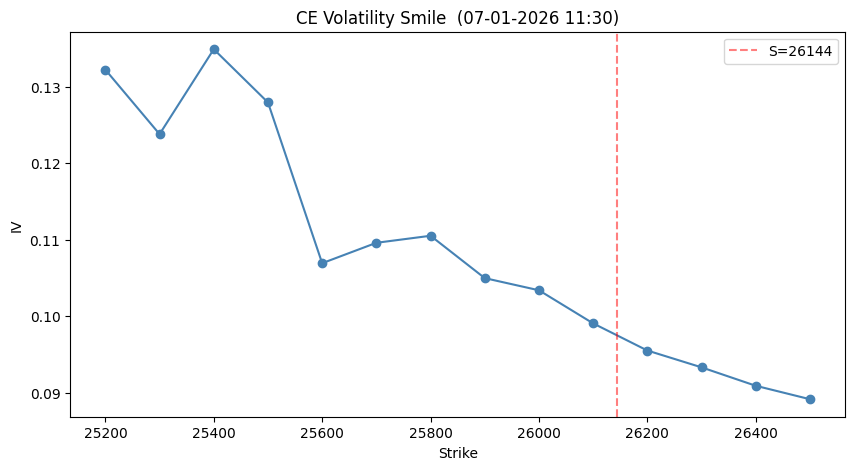

In [8]:
sample_row = df.dropna(subset=ce_cols).iloc[0]
S_sample  = sample_row["underlying_price"]

ce_strikes = [col_meta[c]["strike"] for c in ce_cols]
ce_ivs     = sample_row[ce_cols].values.astype(float)

plt.figure(figsize=(10, 5))
plt.plot(ce_strikes, ce_ivs, marker='o', color='steelblue')
plt.xlabel("Strike"); plt.ylabel("IV")
plt.title(f"CE Volatility Smile  ({sample_row['datetime']})")
plt.axvline(S_sample, color='red', linestyle='--', alpha=0.5, label=f"S={S_sample:.0f}")
plt.legend()
plt.show()

# Tuned Parameters

In [9]:
# Both values were found by systematic Kaggle submission testing.
#
# SHARPNESS = 2300
#   weight(k) = 1 / (1 + log_moneyness(k)^2 * SHARPNESS)
#   At 2300, a strike 10% away from ATM gets weight 1/21 ≈ 5%
#   So the polynomial curve is shaped almost entirely by near-ATM options.
#
# W_POLY = 0.13
#   For EDGE strikes (outside the observed range):
#       pred = 0.13 × polynomial  +  0.87 × linear_slope
#   Slope is computed in raw STRIKE space — more stable than log-moneyness
#   because IV increments per 100-point Nifty strike are roughly constant.

W_POLY    = 0.13
SHARPNESS = 2300

# Main Prediction Logic

In [10]:
filled = df.copy()

for i in range(len(df)):

    row = df.iloc[i]
    S   = row["underlying_price"]

    for opt_cols in [ce_cols, pe_cols]:

        strikes = np.array(
            [col_meta[c]["strike"] for c in opt_cols],
            dtype=float
        )

        iv = row[opt_cols].values.astype(float)

        obs     = ~np.isnan(iv)
        missing = ~obs

        if missing.sum() == 0:
            continue

        obs_idx = np.where(obs)[0]

        lm = np.log(strikes / S)

        degree = min(3, len(obs_idx) - 1)

        # ATM-weighted: near-ATM strikes pull the polynomial curve more strongly
        weights = 1.0 / (1.0 + lm[obs_idx]**2 * SHARPNESS)

        p = np.polyfit(
            lm[obs_idx],
            iv[obs_idx],
            degree,
            w=weights
        )

        for col_idx in np.where(missing)[0]:

            pred_poly = np.polyval(p, lm[col_idx])

            left  = obs_idx[obs_idx < col_idx]
            right = obs_idx[obs_idx > col_idx]

            if len(left) > 0 and len(right) > 0:
                # INTERIOR: missing strike is between two observed strikes
                # Polynomial interpolation is very accurate here
                pred = pred_poly

            else:
                # EDGE: missing strike is beyond the observed range
                # Blend polynomial with a linear slope in RAW STRIKE space
                n1 = obs_idx[0]  if len(left) == 0 else obs_idx[-2]
                n2 = obs_idx[1]  if len(left) == 0 else obs_idx[-1]

                slope    = (iv[n2] - iv[n1]) / (strikes[n2] - strikes[n1])
                pred_lin = iv[n1] + slope * (strikes[col_idx] - strikes[n1])

                pred = W_POLY * pred_poly + (1 - W_POLY) * pred_lin

            filled.at[i, opt_cols[col_idx]] = max(pred, 0.001)

print("NaNs remaining:", filled[iv_cols].isna().sum().sum())

NaNs remaining: 0


# Temporal Fallback

In [11]:
# Safety net: fill any surviving NaN using linear interpolation across time.
# In practice this should always print 0.

for col in iv_cols:

    s  = filled[col].values.copy()
    oi = np.where(~np.isnan(s))[0]
    mi = np.where( np.isnan(s))[0]

    if len(oi) < 2 or len(mi) == 0:
        continue

    fn = interp1d(
        oi.astype(float), s[oi],
        kind="linear",
        bounds_error=False,
        fill_value=(s[oi[0]], s[oi[-1]])
    )

    for pos in mi:
        filled.at[pos, col] = max(float(fn(float(pos))), 0.001)

print("Final NaNs:", filled[iv_cols].isna().sum().sum())

Final NaNs: 0


# Visualise Completed Surface

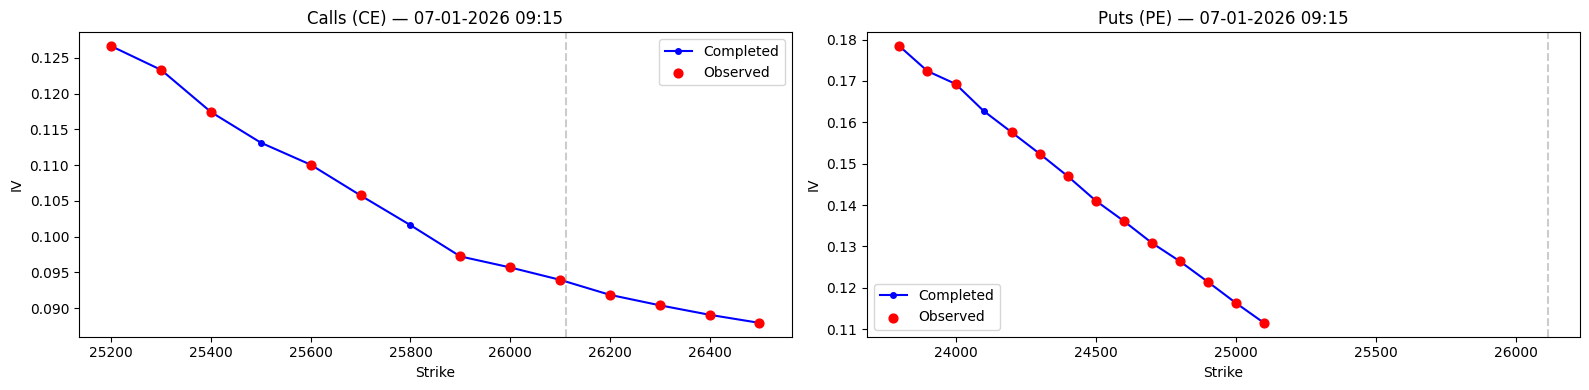

In [12]:
sample_i = df[iv_cols].isna().any(axis=1).idxmax()
S_s      = df.loc[sample_i, "underlying_price"]
dt_s     = df.loc[sample_i, "datetime"]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, opt_cols, title in [
    (axes[0], ce_cols, "Calls (CE)"),
    (axes[1], pe_cols, "Puts (PE)")
]:
    ks      = [col_meta[c]["strike"] for c in opt_cols]
    iv_orig = [df.loc[sample_i, c]     for c in opt_cols]
    iv_fill = [filled.loc[sample_i, c] for c in opt_cols]

    ax.plot(ks, iv_fill, "b-o", ms=4, label="Completed")
    obs_ks = [k for k, v in zip(ks, iv_orig) if not np.isnan(v)]
    obs_vs = [v for v in iv_orig if not np.isnan(v)]
    ax.scatter(obs_ks, obs_vs, c="red", zorder=5, s=40, label="Observed")
    ax.axvline(S_s, color="gray", linestyle="--", alpha=0.4)
    ax.set_xlabel("Strike"); ax.set_ylabel("IV")
    ax.set_title(f"{title} — {dt_s}")
    ax.legend()

plt.tight_layout()
plt.show()

# Save filled_dataset.csv


The official converter script then reads this file to produce `submission.csv`.

In [13]:
# Save the completed dataset (all NaNs filled)
filled.to_csv("filled_dataset.csv", index=False)

print(f"filled_dataset.csv saved — {filled.shape[0]} rows × {filled.shape[1]} columns")
print(f"NaN check: {filled[iv_cols].isna().sum().sum()} missing values remaining")

filled_dataset.csv saved — 975 rows × 30 columns
NaN check: 0 missing values remaining


# Generate Submission — Official Competition Converter

This is the **exact script provided by the competition**.
It reads `filled_dataset.csv` and produces `submission.csv`.

In [14]:
ORIGINAL_DATASET_PATH = "dataset.csv"
SEPARATOR             = "||"

def generate_solution(filled_path: str, output_path: str = "solution.csv"):

    original = pd.read_csv(ORIGINAL_DATASET_PATH)
    filled_  = pd.read_csv(filled_path)

    feature_cols = [c for c in original.columns if c != "datetime"]

    rows = []

    for col in feature_cols:
        was_missing = original[col].isna()

        for idx in original.index[was_missing]:
            dt  = original.loc[idx, "datetime"]
            uid = f"{dt}{SEPARATOR}{col}"
            val = filled_.loc[idx, col]
            rows.append({"id": uid, "value": val})

    solution = pd.DataFrame(rows, columns=["id", "value"])
    solution = solution.sort_values("id").reset_index(drop=True)
    solution.to_csv(output_path, index=False)

    print(f"Solution saved → {output_path}  ({len(solution)} rows)")

generate_solution("filled_dataset.csv", "submission.csv")

Solution saved → submission.csv  (5460 rows)


# Validation

In [15]:
submission = pd.read_csv("submission.csv")

expected = df[iv_cols].isna().sum().sum()

assert len(submission) == expected,                             f"Row count wrong: {len(submission)} vs {expected}"
assert submission["value"].isna().sum() == 0,                  "NaN values found"
assert (submission["value"] > 0).all(),                        "Non-positive IVs found"
assert submission["id"].str.contains("||", regex=False).all(), "Bad id format"
assert submission["id"].nunique() == len(submission),          "Duplicate IDs found"

print("All checks passed ✓")
print()
print(submission["value"].describe().round(6))
print()
print(submission.head(10))

All checks passed ✓

count    5460.000000
mean        0.186987
std         0.257740
min         0.024954
25%         0.110241
50%         0.130708
75%         0.167520
max         5.792004
Name: value, dtype: float64

                                      id     value
0  07-01-2026 09:15||NIFTY27JAN2624100PE  0.162759
1  07-01-2026 09:15||NIFTY27JAN2625500CE  0.113130
2  07-01-2026 09:15||NIFTY27JAN2625800CE  0.101605
3  07-01-2026 09:20||NIFTY27JAN2624000PE  0.169461
4  07-01-2026 09:20||NIFTY27JAN2624200PE  0.158831
5  07-01-2026 09:20||NIFTY27JAN2624800PE  0.128172
6  07-01-2026 09:20||NIFTY27JAN2625000PE  0.118406
7  07-01-2026 09:20||NIFTY27JAN2625300CE  0.101984
8  07-01-2026 09:20||NIFTY27JAN2625400CE  0.108209
9  07-01-2026 09:20||NIFTY27JAN2625800CE  0.108085


# Download Submission

In [16]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>